# Analysis of Residual Stream Activation Vectors

**Input files**:
- `INPUT_FILE` — a single `.pt` reasoning-vectors file produced by `run_fw_pass.py --type reasoning`. Each layer contains:
  - `mean_correct_token`: global average of every correct reasoning token `[d_model]`
  - `mean_incorrect_token`: global average of every incorrect reasoning token `[d_model]`
  - `reasoning_direction_token`: `mean_correct_token - mean_incorrect_token` `[d_model]`
  - `per_sample_means`: per-sample average activation `[N_samples, d_model]`
  - `mean_correct_samples`: mean activation of perfectly-correct samples `[d_model]`
  - `mean_incorrect_samples`: mean activation of flawed samples `[d_model]`
  - `reasoning_direction_sample`: `mean_correct_samples - mean_incorrect_samples` `[d_model]`
- `BASELINE_PCA_FILE` — a `.pt` file with FineWeb PCA components produced by `run_fw_pass.py --type baseline`. Keys: `{"layers": {<int layer>: tensor[n_components, d_model], ...}}`
- `OUTPUT_FILE` — where the enriched `.pt` file (input + cleaned directions) is saved.

**Analysis done**:
- Token and sample level (cosine) similarity of activations for reasoning (ProcessBench) dataset
- Unsupervised clustering method (Principal component analysis) for per-sample activation means
- De-confounding with baseline (FineWeb) principal components (project out of reasoning vectors)

## Set-up

In [2]:
!pip install matplotlib seaborn scikit-learn numpy torch --quiet

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
import copy
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

In [ ]:
# ── File paths ────────────────────────────────────────────────────────────────
INPUT_FILE        = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_Qwen3-8B_processbench.pt"          # single reasoning-vectors file
BASELINE_PCA_FILE_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/fineweb_pca_components.pt"     # FineWeb PCA components
BASELINE_PCA_FILE_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/deepmind_math_pca_components_20000samples.pt"
BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/joint_pca_fineweb_deepmind_40000samples.pt"
OUTPUT_FILE       = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_joint_fineweb_deepmind_math.pt"   # enriched output
# ─────────────────────────────────────────────────────────────────────────────

## Load input file

In [5]:
data = torch.load(INPUT_FILE, map_location="cpu")

meta   = data["metadata"]
layers = data["layers"]

# Sort layer names by their integer index (e.g. "blocks.18.hook_out" → 18)
sorted_layer_names = sorted(
    layers.keys(),
    key=lambda x: int(x.split(".")[1])
)

# Per-sample correctness mask
is_perfect_mask = meta["per_sample_is_fully_correct"]   # bool tensor [N_samples]
y_mask          = is_perfect_mask.numpy()

print(f"Model          : {meta.get('model', 'N/A')}")
print(f"Target layers  : {meta.get('target_layers', 'N/A')}")
print(f"Correct tokens : {meta.get('count_correct_tokens', 'N/A')}")
print(f"Incorrect toks : {meta.get('count_incorrect_tokens', 'N/A')}")
print(f"Perfect samples: {is_perfect_mask.sum().item()}")
print(f"Flawed samples : {(~is_perfect_mask).sum().item()}")
print(f"Layers found   : {sorted_layer_names}")

Model          : Qwen/Qwen3-8B
Target layers  : [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Correct tokens : 1209005
Incorrect toks : 1083086
Perfect samples: 1178
Flawed samples : 2218
Layers found   : ['blocks.18.hook_out', 'blocks.19.hook_out', 'blocks.20.hook_out', 'blocks.21.hook_out', 'blocks.22.hook_out', 'blocks.23.hook_out', 'blocks.24.hook_out', 'blocks.25.hook_out', 'blocks.26.hook_out', 'blocks.27.hook_out', 'blocks.28.hook_out']


## Layer statistics - Token and sample level (cosine) similarity

- **Token-level cosine similarity**: angle between the global-average correct-token vector and the global-average incorrect-token vector. Values close to 1 indicate the model's activation is in roughly the same direction for both classes — most of the vector's "volume" is shared language-modeling signal.
- **Sample-level cosine similarity**: same idea but for the per-sample means (one vector per problem, averaged within each class).
- **Steering vector magnitude**: L2 norm of `reasoning_direction_token / reasoning_direction_sample` — the absolute geometric distance between the two class centres.

=== Layer Statistics ===
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.995433
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.993951
  Cosine Sim (Token Dir vs Sample Dir): 0.721687
  Token  Steering Vec Magnitude: 7.4717
  Sample Steering Vec Magnitude: 9.1812
Layer blocks.18.hook_out  |  token: 0.9954  |  sample: 0.9940  |  alignment: 0.7217
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993901
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.994053
  Cosine Sim (Token Dir vs Sample Dir): 0.706868
  Token  Steering Vec Magnitude: 9.8716
  Sample Steering Vec Magnitude: 10.2663
Layer blocks.19.hook_out  |  token: 0.9939  |  sample: 0.9941  |  alignment: 0.7069
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993841
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.994051
  Cosine Sim (Token Dir vs Sample Dir): 0.688282
  Token  Steering Vec Magnitude: 10.1103
  Sample Steering Vec Magnitude: 10.4292
Layer blocks.20.hook_out  |  token: 0.9938  |  sample: 0.

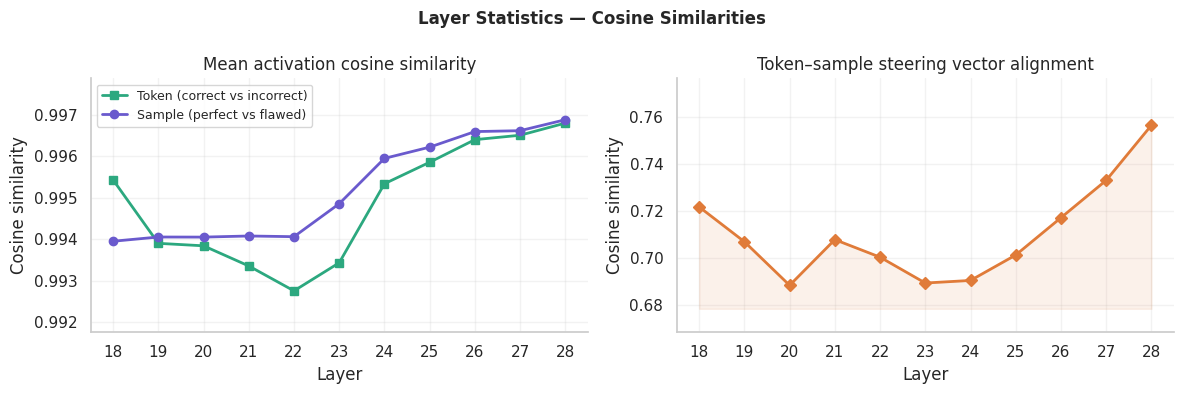

In [6]:
print("=== Layer Statistics ===")

sorted_layer_names = sorted(layers.keys())
layer_indices = [int(name.split(".")[1]) for name in sorted_layer_names]

token_cos_sim, sample_cos_sim, tok_samp_sim = [], [], []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    token_sim = F.cosine_similarity(
        ld["mean_correct_token"].unsqueeze(0),
        ld["mean_incorrect_token"].unsqueeze(0)
    ).item()
    print(f"  Token-Level  Cosine Sim  (Correct vs Incorrect): {token_sim:.6f}")

    sample_sim = F.cosine_similarity(
        ld["mean_correct_samples"].unsqueeze(0),
        ld["mean_incorrect_samples"].unsqueeze(0)
    ).item()
    print(f"  Sample-Level Cosine Sim  (Perfect vs Flawed):    {sample_sim:.6f}")


    alignment = F.cosine_similarity(
        ld["reasoning_direction_token"].unsqueeze(0),
        ld["reasoning_direction_sample"].unsqueeze(0)
    ).item()
    print(f"  Cosine Sim (Token Dir vs Sample Dir): {alignment:.6f}")

    # Steering vector magnitudes
    token_mag  = torch.norm(ld["reasoning_direction_token"]).item()
    sample_mag = torch.norm(ld["reasoning_direction_sample"]).item()
    print(f"  Token  Steering Vec Magnitude: {token_mag:.4f}")
    print(f"  Sample Steering Vec Magnitude: {sample_mag:.4f}")

    token_cos_sim.append(token_sim)
    sample_cos_sim.append(sample_sim)
    tok_samp_sim.append(alignment)

    print(f"Layer {layer_name}  |  token: {token_sim:.4f}  |  sample: {sample_sim:.4f}  |  alignment: {alignment:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
PURPLE, GREEN, ORANGE = "#6a5acd", "#2ca87f", "#e07b39"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Layer Statistics — Cosine Similarities", fontsize=12, fontweight="bold")

ax1.plot(layer_indices, token_cos_sim,  "s-", color=GREEN,  lw=2, label="Token (correct vs incorrect)")
ax1.plot(layer_indices, sample_cos_sim, "o-", color=PURPLE, lw=2, label="Sample (perfect vs flawed)")
ax1.set_title("Mean activation cosine similarity")
ax1.set_ylabel("Cosine similarity")
ax1.set_ylim(min(token_cos_sim + sample_cos_sim) - 0.001,
             max(token_cos_sim + sample_cos_sim) + 0.001)
ax1.legend(fontsize=9)

ax2.plot(layer_indices, tok_samp_sim, "D-", color=ORANGE, lw=2)
ax2.fill_between(layer_indices, tok_samp_sim,
                 min(tok_samp_sim) - 0.01, color=ORANGE, alpha=0.1)
ax2.set_title("Token–sample steering vector alignment")
ax2.set_ylabel("Cosine similarity")
ax2.set_ylim(min(tok_samp_sim) - 0.02, max(tok_samp_sim) + 0.02)

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(layer_indices)
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("layer_cosine_similarities.png", dpi=150, bbox_inches="tight")
plt.show()

- Calculate the cosine similarity between correct and incorrect reasoning vectors across all targeted layers. If the similarity is low, it suggests the model is in a distinctly different state when hallucinating / incorrectly reasoning versus when reasoning correctly.


## Unsupervised method - Principal component analysis

PCA finds the directions of maximum variance in the per-sample activation means. If correct and incorrect samples cluster separately along PC1/PC2, the correctness signal is strong enough to dominate the variance. If they overlap, the dominant variance axes are driven by other confounds (problem topic, vocabulary, etc.) and the correctness signal is buried deeper — motivating the de-confounding step below.

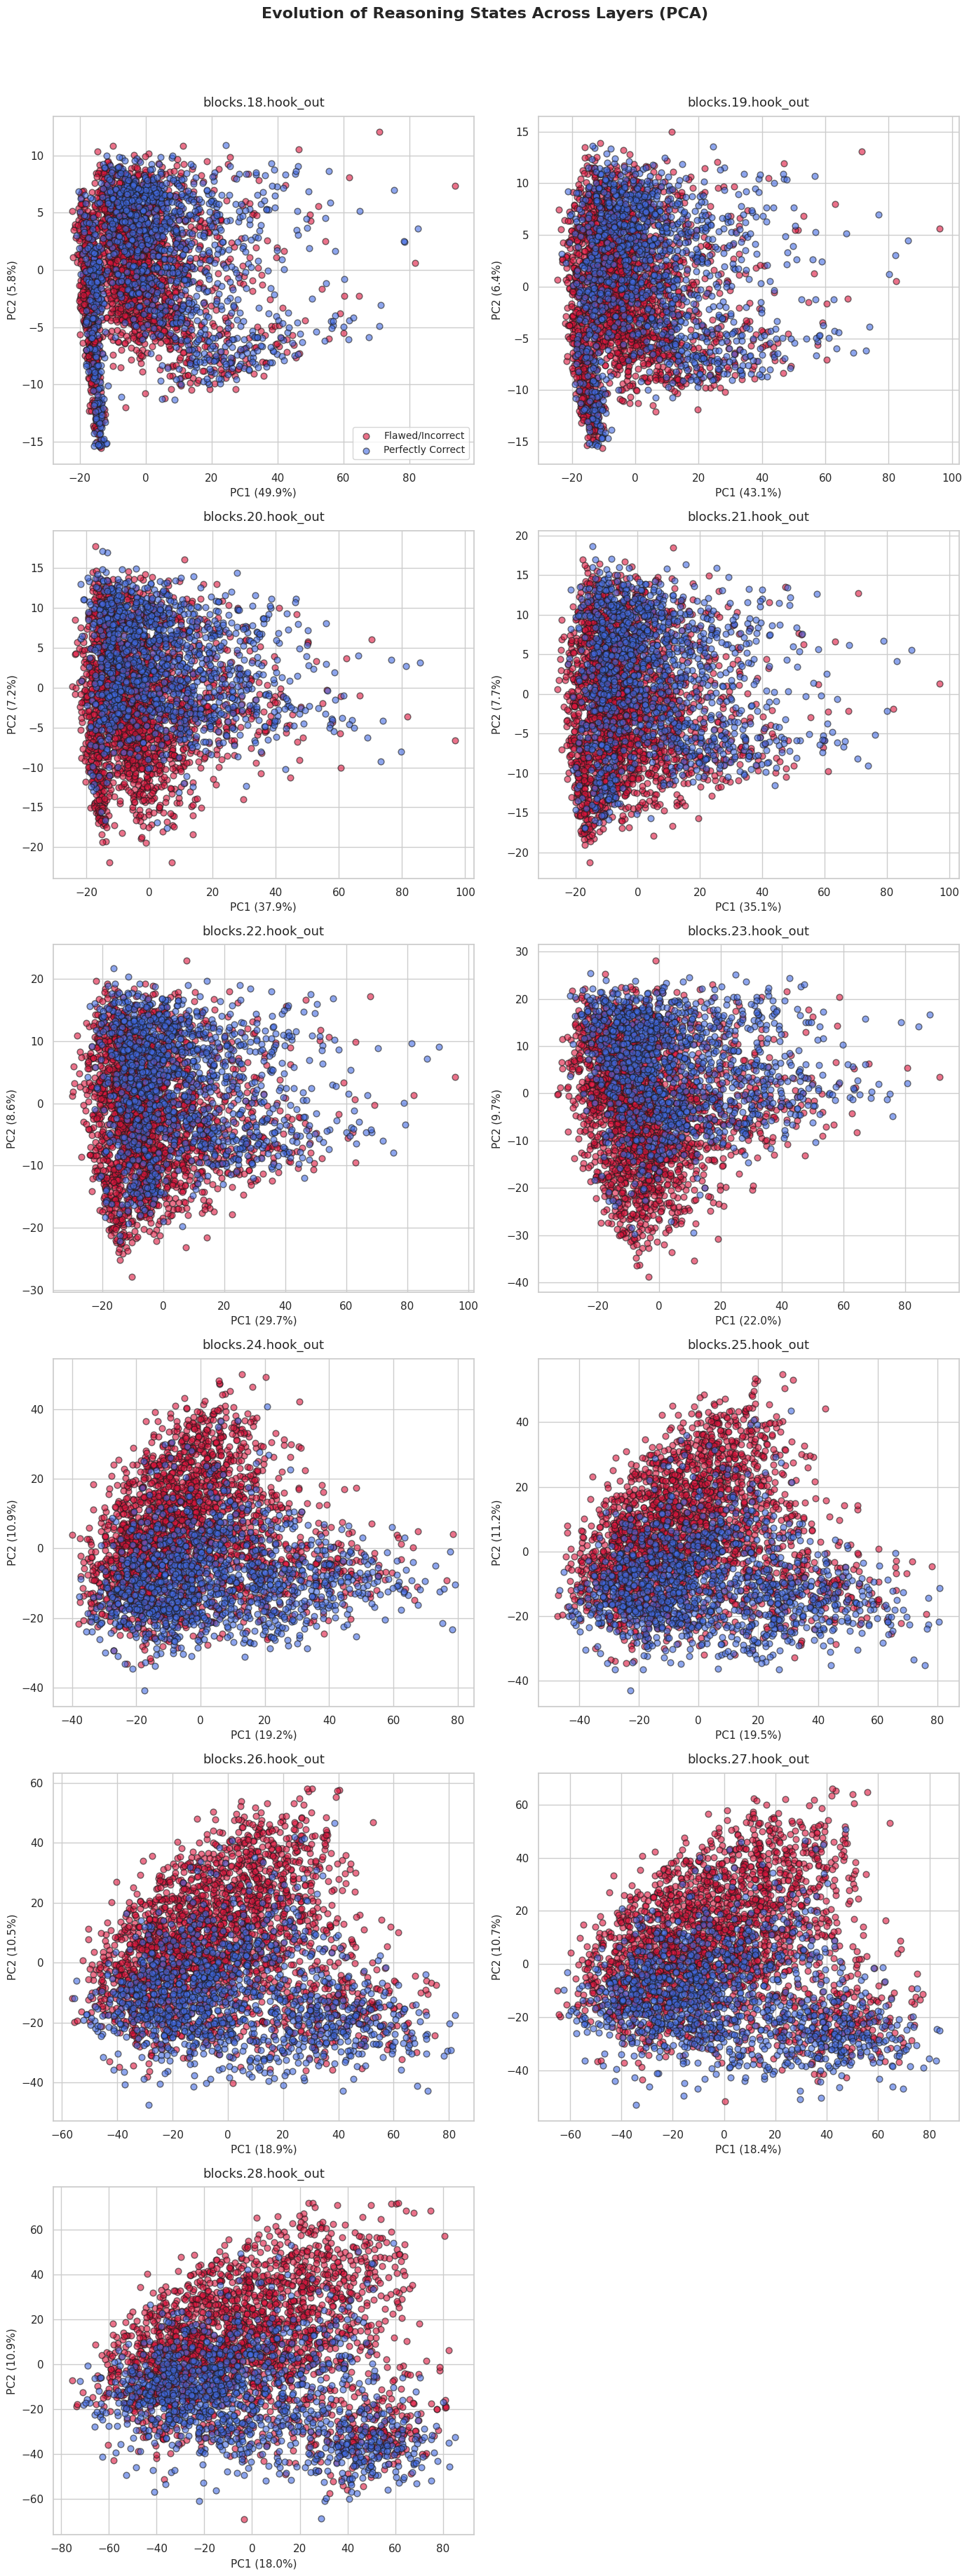

In [7]:
num_layers = len(sorted_layer_names)
cols = 2
rows = math.ceil(num_layers / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
axes = axes.flatten() if num_layers > 1 else [axes]

for i, layer_name in enumerate(sorted_layer_names):
    ax  = axes[i]
    ld  = layers[layer_name]
    X   = ld["per_sample_means"].to(torch.float32).numpy()

    pca   = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    var   = pca.explained_variance_ratio_

    ax.scatter(X_pca[~y_mask, 0], X_pca[~y_mask, 1],
               alpha=0.6, color="crimson",    edgecolor="k", s=40, label="Flawed/Incorrect")
    ax.scatter(X_pca[ y_mask, 0], X_pca[ y_mask, 1],
               alpha=0.6, color="royalblue",  edgecolor="k", s=40, label="Perfectly Correct")

    ax.set_title(layer_name, fontsize=13, pad=10)
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)", fontsize=11)
    if i == 0:
        ax.legend(fontsize=10)

for j in range(num_layers, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Evolution of Reasoning States Across Layers (PCA)",
             fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## Load baseline PCA components

In [12]:
baseline_pca = torch.load(BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH, map_location="cpu")
pca_by_layer = baseline_pca["layers"]   # keys are int layer indices

def get_baseline_components_old(layer_name: str):
    """
    Look up PCA components for a layer whose name is e.g. 'blocks.18.hook_out'.
    The baseline file uses integer keys (18, 19, …).
    Returns a numpy array of shape [n_components, d_model].
    """
    return pca_by_layer[layer_name].to(torch.float32).numpy()
    
def get_baseline_components(layer_name: str):
    """
    Look up PCA components for a layer whose name is e.g. 'blocks.18.hook_out'.
    This unified version supports dictionaries with either string keys or integer keys.
    Returns a numpy array of shape [n_components, d_model].
    """
    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        return pca_by_layer[layer_name].to(torch.float32).numpy()
    
    # Option 2: The dictionary uses integer keys (fallback)
    try:
        layer_idx = int(layer_name.split(".")[1])
        return pca_by_layer[layer_idx].to(torch.float32).numpy()
    except (IndexError, ValueError) as e:
        raise KeyError(f"Could not find key '{layer_name}' or its integer index in pca_by_layer.") from e
    
def project_out_components(vec: torch.Tensor, components: np.ndarray) -> torch.Tensor:
    """
    Project out a set of (orthogonal, unit-norm) PCA components from a vector.
    Works for both 1-D vectors [d_model] and 2-D matrices [N, d_model].
    """
    x = vec.to(torch.float32).numpy().copy()
    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)
    for comp in components:                              # comp: [d_model]
        projection = x @ comp                           # [N]
        x -= projection[:, None] * comp[None, :]        # subtract component
    return torch.tensor(x.reshape(original_shape), dtype=vec.dtype)


print("Baseline PCA file loaded.")
print(f"Layers in baseline file: {list(pca_by_layer.keys())}")

Baseline PCA file loaded.
Layers in baseline file: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## Project baseline (FineWeb) PCA components out of the reasoning vectors

We subtract the projection of each steering vector onto the FineWeb PCA subspace. This removes variance that is shared with generic language processing, leaving a cleaner signal that is more specific to the *correctness* of mathematical reasoning.

=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (3 components)  |  token: 7.472→6.250 (54.8%)  |  sample: 9.181→5.247 (82.1%)
Layer blocks.19.hook_out  (3 components)  |  token: 9.872→8.503 (50.8%)  |  sample: 10.266→6.563 (76.9%)
Layer blocks.20.hook_out  (3 components)  |  token: 10.110→9.129 (43.0%)  |  sample: 10.429→7.437 (70.1%)
Layer blocks.21.hook_out  (3 components)  |  token: 11.580→10.436 (43.3%)  |  sample: 11.680→8.265 (70.7%)
Layer blocks.22.hook_out  (3 components)  |  token: 13.497→12.601 (35.8%)  |  sample: 12.988→10.210 (61.8%)
Layer blocks.23.hook_out  (3 components)  |  token: 15.667→15.400 (18.4%)  |  sample: 14.263→12.924 (42.3%)
Layer blocks.24.hook_out  (4 components)  |  token: 17.630→17.541 (10.0%)  |  sample: 16.461→16.121 (20.2%)
Layer blocks.25.hook_out  (4 components)  |  token: 18.801→18.549 (16.3%)  |  sample: 17.944→17.770 (13.9%)
Layer blocks.26.hook_out  (3 components)  |  token: 20.597→20.235 (18.7%)  |  sample: 19.951→19.709

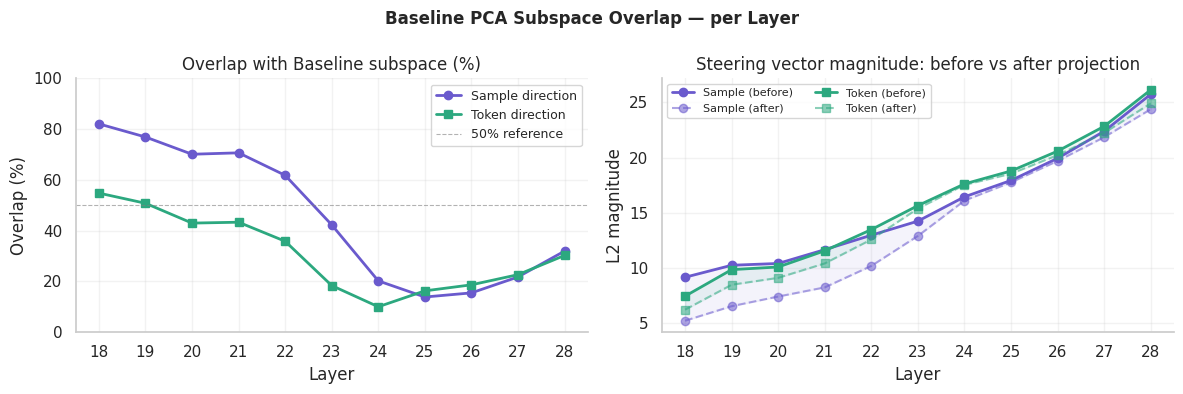

In [15]:
print("=== Projecting out baseline PCA components ===")

token_overlap_pct, sample_overlap_pct = [], []
token_mag_before,  token_mag_after    = [], []
sample_mag_before, sample_mag_after   = [], []
valid_layer_indices = []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError as e:
        print(f"  WARNING: {e}. Skipping layer.")
        continue

    n_comp = components.shape[0]

    rd_token  = ld["reasoning_direction_token"]
    rd_sample = ld["reasoning_direction_sample"]

    rd_token_cleaned  = project_out_components(rd_token,  components)
    rd_sample_cleaned = project_out_components(rd_sample, components)
    ld["reasoning_direction_token_cleaned"]  = rd_token_cleaned
    ld["reasoning_direction_sample_cleaned"] = rd_sample_cleaned

    orig_token_mag   = torch.norm(rd_token).item()
    clean_token_mag  = torch.norm(rd_token_cleaned).item()
    orig_sample_mag  = torch.norm(rd_sample).item()
    clean_sample_mag = torch.norm(rd_sample_cleaned).item()

    dot_token  = torch.tensor(np.array([
        np.dot(rd_token.to(torch.float32).numpy()  / (orig_token_mag  + 1e-12), c)
        for c in components]))
    dot_sample = torch.tensor(np.array([
        np.dot(rd_sample.to(torch.float32).numpy() / (orig_sample_mag + 1e-12), c)
        for c in components]))

    overlap_token  = torch.sqrt((dot_token**2).sum()).item()
    overlap_sample = torch.sqrt((dot_sample**2).sum()).item()

    token_overlap_pct.append(overlap_token   * 100)
    sample_overlap_pct.append(overlap_sample * 100)
    token_mag_before.append(orig_token_mag);   token_mag_after.append(clean_token_mag)
    sample_mag_before.append(orig_sample_mag); sample_mag_after.append(clean_sample_mag)
    valid_layer_indices.append(int(layer_name.split(".")[1]))

    print(f"Layer {layer_name}  ({n_comp} components)  |  "
          f"token: {orig_token_mag:.3f}→{clean_token_mag:.3f} ({overlap_token*100:.1f}%)  |  "
          f"sample: {orig_sample_mag:.3f}→{clean_sample_mag:.3f} ({overlap_sample*100:.1f}%)")

print("\n=== Projection complete ===")

# ── Plot ──────────────────────────────────────────────────────────────────
PURPLE, GREEN = "#6a5acd", "#2ca87f"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline PCA Subspace Overlap — per Layer", fontsize=12, fontweight="bold")

# Left: overlap %
ax1.plot(valid_layer_indices, sample_overlap_pct, "o-", color=PURPLE, lw=2, label="Sample direction")
ax1.plot(valid_layer_indices, token_overlap_pct,  "s-", color=GREEN,  lw=2, label="Token direction")
ax1.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% reference")
ax1.set_title("Overlap with Baseline subspace (%)")
ax1.set_ylabel("Overlap (%)")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=9)

# Right: magnitude before vs after
ax2.plot(valid_layer_indices, sample_mag_before, "o-",  color=PURPLE, lw=2,   label="Sample (before)")
ax2.plot(valid_layer_indices, sample_mag_after,  "o--", color=PURPLE, lw=1.5, alpha=0.55, label="Sample (after)")
ax2.plot(valid_layer_indices, token_mag_before,  "s-",  color=GREEN,  lw=2,   label="Token (before)")
ax2.plot(valid_layer_indices, token_mag_after,   "s--", color=GREEN,  lw=1.5, alpha=0.55, label="Token (after)")
ax2.fill_between(valid_layer_indices, sample_mag_after, sample_mag_before, color=PURPLE, alpha=0.07)
ax2.fill_between(valid_layer_indices, token_mag_after,  token_mag_before,  color=GREEN,  alpha=0.07)
ax2.set_title("Steering vector magnitude: before vs after projection")
ax2.set_ylabel("L2 magnitude")
ax2.legend(fontsize=8, ncol=2)

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(valid_layer_indices)
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fineweb_overlap_projection.png", dpi=150, bbox_inches="tight")
plt.show()

**FINEWEB**
=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (4 components)  |  token: 7.472→6.207 (55.7%)  |  sample: 9.181→5.214 (82.3%)
Layer blocks.19.hook_out  (5 components)  |  token: 9.872→8.436 (51.9%)  |  sample: 10.266→6.515 (77.3%)
Layer blocks.20.hook_out  (7 components)  |  token: 10.110→8.846 (48.4%)  |  sample: 10.429→7.233 (72.0%)
Layer blocks.21.hook_out  (7 components)  |  token: 11.580→10.194 (47.4%)  |  sample: 11.680→8.065 (72.3%)
Layer blocks.22.hook_out  (8 components)  |  token: 13.497→11.293 (54.8%)  |  sample: 12.988→9.817 (65.5%)
Layer blocks.23.hook_out  (10 components)  |  token: 15.667→13.883 (46.3%)  |  sample: 14.263→12.085 (53.1%)
Layer blocks.24.hook_out  (13 components)  |  token: 17.630→15.594 (46.7%)  |  sample: 16.461→14.186 (50.7%)
Layer blocks.25.hook_out  (16 components)  |  token: 18.801→16.905 (43.8%)  |  sample: 17.944→15.580 (49.6%)
Layer blocks.26.hook_out  (19 components)  |  token: 20.597→18.287 (46.0%)  |  sample: 19.951→17.382 (49.1%)
Layer blocks.27.hook_out  (21 components)  |  token: 22.843→20.159 (47.0%)  |  sample: 22.397→19.449 (49.6%)
Layer blocks.28.hook_out  (23 components)  |  token: 26.142→22.869 (48.5%)  |  sample: 25.742→22.158 (50.9%)

=== Projection complete ===

- Finding 1: Sample directions are heavily contaminated by generic text features — especially early on
The most striking pattern is the gap between sample-level and token-level FineWeb overlap. At layer 18, the sample direction has 82% of its magnitude inside the FineWeb subspace, compared to only 56% for the token direction. This gap shrinks progressively across layers until both converge near ~50% at layer 28.
This tells you that sample-level steering vectors (averaged over whole completions) pick up a lot of stylistic, surface-level text variation — exactly what FineWeb PCA captures. The token direction, by contrast, is more "targeted" from the start, implying it tracks something more specifically tied to local reasoning correctness rather than general fluency patterns.


- Finding 2: The subspace itself grows in dimensionality with depth
The number of PCA components needed to explain the FineWeb baseline grows from 4 (layer 18) to 23 (layer 28). This reflects the known phenomenon where later transformer layers have higher intrinsic dimensionality in their activation geometry — the model is encoding richer, more distributed representations. Accordingly, more components are needed to span the "generic text" subspace.
- Finding 3: Reasoning directions are tiny perturbations in a high-cosine-sim space
The token-level and sample-level cosine similarities between correct/incorrect activations are all above 0.99 — meaning the model's activations for good and bad reasoning are almost collinear. The steering vectors you're extracting represent extremely small angular deviations from nearly identical mean activations. This is important: it means the "reasoning quality" signal is geometrically subtle, and any contamination from generic text directions is a real concern.
- Finding 4: Token and sample directions converge in deeper layers
The cosine similarity between the token direction and sample direction increases from 0.72 at layer 18 to 0.76 at layer 28. Combined with the decreasing FineWeb overlap gap, this suggests that as depth increases, both methods of extracting a reasoning direction are pointing at more of the same thing — a more consolidated, task-specific representation.
- Finding 5: ~50% residual overlap is a floor, not noise
Even after convergence in later layers, both directions retain ~47–51% overlap with FineWeb. This is not trivially explained by chance alignment in high-dimensional space — it suggests that the model's reasoning quality signal genuinely shares subspace with how it represents generic text. The mechanisms that produce fluent web text and those that support correct multi-step reasoning are not cleanly separable in activation space


The results paint a consistent picture: early layers cannot cleanly separate reasoning quality from generic fluency — sample-level directions especially are dominated by FineWeb-like features. As depth increases, this contamination decays, both directions converge, and the representation becomes more task-specific. However, a persistent ~50% floor in FineWeb overlap across all later layers suggests the model does not develop an orthogonal "reasoning subspace" — instead, reasoning quality is encoded in a direction that remains partially entangled with general language representations even in deep layers.
The practical implication is that if you're doing activation steering or probing for reasoning quality, later layers (24+) are cleaner targets, and token-level directions are more reliable than sample-level — especially in early-to-mid layers where sample averaging mixes reasoning signal with stylistic noise.

## Save output file

The output `.pt` file is identical to the input, with two additional keys per layer:
- `reasoning_direction_token_cleaned`
- `reasoning_direction_sample_cleaned`

In [16]:
# data["layers"] was modified in-place above, so we can save directly.
torch.save(data, OUTPUT_FILE)
print(f"Saved enriched reasoning vectors to '{OUTPUT_FILE}'.")

# Verify
check = torch.load(OUTPUT_FILE, map_location="cpu")
sample_layer = sorted_layer_names[0]
keys = list(check["layers"][sample_layer].keys())
print(f"Keys in '{sample_layer}': {keys}")

Saved enriched reasoning vectors to '/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_joint_fineweb_deepmind_math.pt'.
Keys in 'blocks.18.hook_out': ['mean_correct_token', 'mean_incorrect_token', 'reasoning_direction_token', 'per_sample_means', 'mean_correct_samples', 'mean_incorrect_samples', 'reasoning_direction_sample', 'reasoning_direction_token_cleaned', 'reasoning_direction_sample_cleaned']


In [18]:
print("=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===")

for layer_name in sorted_layer_names:
    # components = pca_by_layer[layer_name].to(torch.float32)   # [n_comp, d_model]

    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        components =  pca_by_layer[layer_name].to(torch.float32)
    # Option 2: The dictionary uses integer keys (fallback)
    else:
        layer_idx = int(layer_name.split(".")[1])
        components =  pca_by_layer[layer_idx].to(torch.float32)
    
    n_comp = components.shape[0]

    ld = layers[layer_name]

    for vec_key, label in [
        ("reasoning_direction_token",  "Token  direction"),
        ("reasoning_direction_sample", "Sample direction"),
    ]:
        v = ld[vec_key].to(torch.float32)
        v_norm = torch.norm(v)
        if v_norm == 0:
            print(f"  {label}: zero vector, skipping.")
            continue

        v_unit = v / v_norm

        # Cosine similarity of the (unit) steering vector against every PCA component at once.
        # components rows are already unit vectors, so matmul gives exact cosine sims.
        dot_products = components @ v_unit                          # [n_comp]

        max_cos_sim        = torch.max(torch.abs(dot_products)).item()
        total_subspace_overlap = torch.sqrt((dot_products**2).sum()).item()

        print(f"\nLayer: {layer_name}  |  {label}  ({n_comp} PCA components)")
        print(f"  Max cosine sim with any single component : {max_cos_sim:.4f}")
        print(f"  Total subspace overlap ratio             : {total_subspace_overlap:.4f} "
              f"({total_subspace_overlap*100:.1f}% of vector magnitude lies in Baseline subspace)")

print("\n=== Overlap analysis complete ===")

=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===

Layer: blocks.18.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.5246
  Total subspace overlap ratio             : 0.5480 (54.8% of vector magnitude lies in Baseline subspace)

Layer: blocks.18.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.7633
  Total subspace overlap ratio             : 0.8206 (82.1% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.4634
  Total subspace overlap ratio             : 0.5080 (50.8% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.6617
  Total subspace overlap ratio             : 0.7690 (76.9% of vector magnitude lies in Baseline subspace)

Layer: blocks.20.hook_out

=== Analyzing Overlap: Reasoning Vectors vs FineWeb PCA Subspace ===

Layer: blocks.18.hook_out  |  Token  direction  (4 PCA components)
  Max cosine sim with any single component : 0.5361
  Total subspace overlap ratio             : 0.5567 (55.7% of vector magnitude lies in FineWeb subspace)

Layer: blocks.18.hook_out  |  Sample direction  (4 PCA components)
  Max cosine sim with any single component : 0.8184
  Total subspace overlap ratio             : 0.8231 (82.3% of vector magnitude lies in FineWeb subspace)

Layer: blocks.19.hook_out  |  Token  direction  (5 PCA components)
  Max cosine sim with any single component : 0.4942
  Total subspace overlap ratio             : 0.5194 (51.9% of vector magnitude lies in FineWeb subspace)

Layer: blocks.19.hook_out  |  Sample direction  (5 PCA components)
  Max cosine sim with any single component : 0.7652
  Total subspace overlap ratio             : 0.7729 (77.3% of vector magnitude lies in FineWeb subspace)

Layer: blocks.20.hook_out  |  Token  direction  (7 PCA components)
  Max cosine sim with any single component : 0.4224
  Total subspace overlap ratio             : 0.4842 (48.4% of vector magnitude lies in FineWeb subspace)

Layer: blocks.20.hook_out  |  Sample direction  (7 PCA components)
  Max cosine sim with any single component : 0.6972
  Total subspace overlap ratio             : 0.7204 (72.0% of vector magnitude lies in FineWeb subspace)
...
  Max cosine sim with any single component : 0.3397
  Total subspace overlap ratio             : 0.5090 (50.9% of vector magnitude lies in FineWeb subspace)

=== Overlap analysis complete ===

## Analysis of PCA Projection Results

This experiment projects out **FineWeb baseline PCA components** (generic web-text statistics) from steering vectors that separate *correct vs. incorrect* (token-level) and *perfect vs. flawed* (sample-level) representations, across layers 18–28 of a transformer.

---

### 1. Overlap with FineWeb Subspace — The Core Finding

| Layer | Token overlap | Sample overlap |
|-------|--------------|----------------|
| 18 | 55.7% | **82.3%** |
| 23 | 46.3% | 53.1% |
| 28 | 48.5% | 50.9% |

**The sample-level direction starts almost entirely explained by generic web-text statistics (82%), and progressively disentangles from them toward deeper layers (~50%).** The token-level direction is already more task-specific early on (~56%), and remains roughly stable.

**Interpretation:** Early layers primarily encode *distributional, stylistic* properties shared with general web text (FineWeb). As depth increases, representations become progressively more abstract and task-specific — the quality signal is less entangled with generic text statistics.

---

### 2. Steering Vector Magnitudes Grow Monotonically

Both token and sample directions grow steadily with depth (7.5 → 26.1 and 9.2 → 25.7 respectively), which is consistent with the **residual stream accumulating information** across layers. Their ratio stays close to 1, meaning the two levels of comparison remain roughly commensurate throughout.

---

### 3. Cosine Similarity Between Correct/Incorrect Representations is Very High Throughout

Both token-level (~0.993–0.997) and sample-level (~0.994–0.997) cosine similarities are extremely close to 1 at all layers. This means:

- Correct and incorrect representations are **nearly identical geometrically** — quality is encoded in a small directional perturbation on top of a large shared component.
- The steering vectors are **small relative to the ambient representation norm**, which is why they can be confused with baseline PCA components.

There is a subtle **U-shape** in token-level cosine sim (dips at layers 21–23, recovers later), potentially indicating a transition zone where representations are being reorganized before late-layer specialization.

---

### 4. Token vs. Sample Directions Converge in Later Layers

| Layer | Cosine(Token dir, Sample dir) |
|-------|-------------------------------|
| 18 | 0.722 |
| 20–24 | ~0.688–0.708 (dip) |
| 28 | **0.756** |

The alignment between the token-level and sample-level quality directions increases in later layers after a mid-network dip. This suggests that:

- **Early layers** encode quality differently depending on the granularity of comparison (token vs. sample).
- **Later layers** develop a more unified, abstract notion of quality — the token-level and sample-level "what makes a response good" directions become increasingly the same vector.

---

### Summary Interpretation

| Phenomenon | What it means |
|---|---|
| High early FineWeb overlap (esp. sample) | Quality signal early on is entangled with generic web-text style |
| Decreasing overlap with depth | Deeper layers encode more abstract, task-specific quality |
| Very high cosine sims (correct vs incorrect) | Quality is a small perturbation on a large shared representation |
| Token–sample direction convergence at depth | Later layers unify token and sample quality into one coherent direction |
| Monotonically growing magnitudes | Residual stream accumulates signal; deeper = stronger steering vectors |

The overall picture is one of **progressive abstraction**: early layers conflate quality with generic distributional properties; later layers distill a cleaner, more universal quality direction that is consistent across both token-level and sample-level comparisons, and increasingly independent of baseline web-text statistics.